# Trajectory Analysis
This notebook loads trajectory data from the current folder, computes the first and second derivatives, and visualizes them to check if changes occur together.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# List trajectory files in the current folder
trajectory_files = [f for f in os.listdir('.') if f.startswith('trajectories_') and f.endswith('.txt')]
print('Found trajectory files:', trajectory_files)
trajectories = []
for fname in trajectory_files:
    data = np.loadtxt(fname)
    trajectories.append(data)
print(f'Loaded {len(trajectories)} trajectories.')

Found trajectory files: ['trajectories_90_to_140.txt', 'trajectories_90_to_20.txt']
Loaded 2 trajectories.


In [3]:
# Compute first and second derivatives for each trajectory (with smoothing)
from scipy.signal import savgol_filter
dt = 0.1  # ms resolution
duration = 650  # ms
time = np.arange(0, duration, dt)
derivatives = []
for traj in trajectories:
    # Ensure trajectory length matches time axis
    if len(traj) != len(time):
        print(f'Warning: trajectory length {len(traj)} does not match expected time axis {len(time)}')
        continue
    # Smooth the trajectory to reduce noise before differentiation
    smoothed_traj = savgol_filter(traj, window_length=11, polyorder=3)
    first_deriv = np.gradient(smoothed_traj, dt)
    second_deriv = np.gradient(first_deriv, dt)
    derivatives.append((first_deriv, second_deriv))
print('Computed derivatives for all trajectories (using smoothed data).')

Computed derivatives for all trajectories (using smoothed data).


First change in trajectory 1 at time 151.4 ms (index 1514): 1.570797
First change in trajectory 2 at time 152.1 ms (index 1521): 1.570795


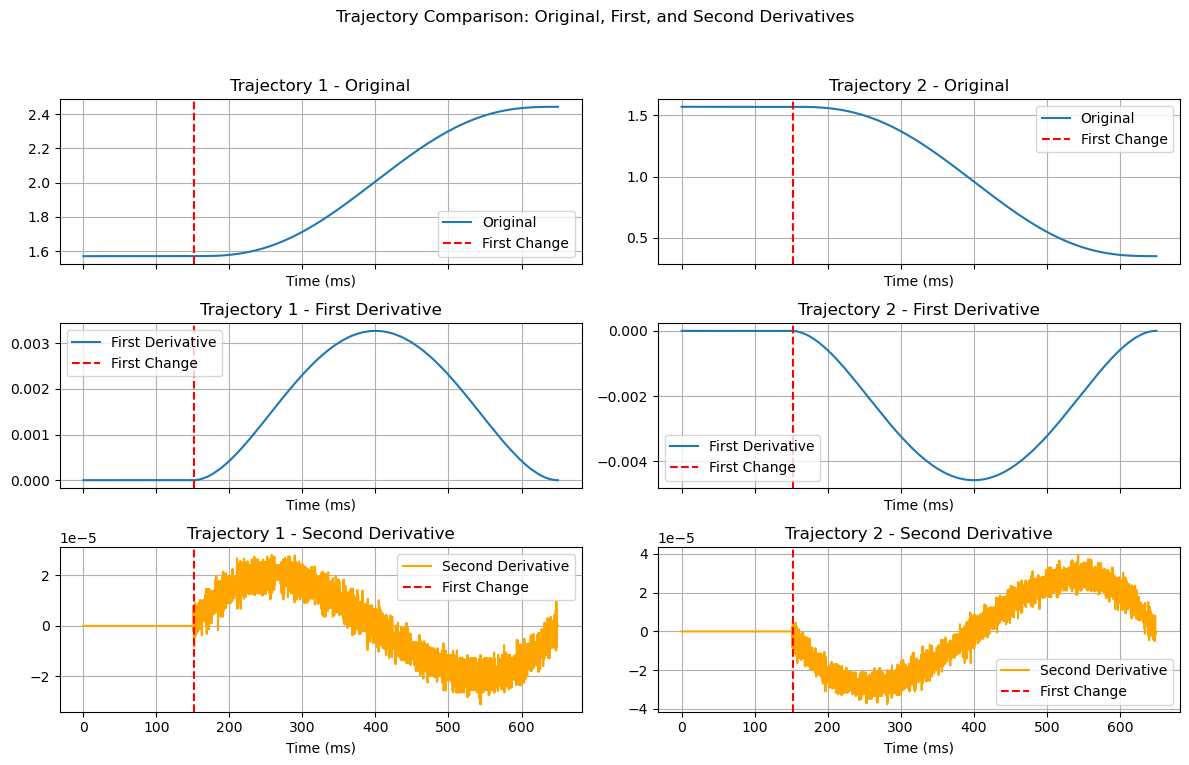

In [4]:
# Visualize: each trajectory in a column, rows for original, first, and second derivatives, with grid for comparison
num_traj = len(derivatives)
fig, axs = plt.subplots(3, num_traj, figsize=(6*num_traj, 8), sharex='col')
for col, ((first_deriv, second_deriv), traj) in enumerate(zip(derivatives, trajectories)):
    if len(traj) != len(time):
        continue
    # Find the first change in trajectory values
    change_idx = np.argmax(traj != traj[0]) if np.any(traj != traj[0]) else None
    if change_idx is not None:
        print(f'First change in trajectory {col+1} at time {time[change_idx]:.1f} ms (index {change_idx}): {traj[change_idx]}')
    axs[0, col].plot(time, traj, label='Original')
    if change_idx is not None:
        axs[0, col].axvline(time[change_idx], color='red', linestyle='--', label='First Change')
    axs[0, col].set_title(f'Trajectory {col+1} - Original')
    axs[0, col].legend()
    axs[0, col].grid(True)
    axs[1, col].plot(time, first_deriv, label='First Derivative')
    if change_idx is not None:
        axs[1, col].axvline(time[change_idx], color='red', linestyle='--', label='First Change')
    axs[1, col].set_title(f'Trajectory {col+1} - First Derivative')
    axs[1, col].legend()
    axs[1, col].grid(True)
    axs[2, col].plot(time, second_deriv, label='Second Derivative', color='orange')
    if change_idx is not None:
        axs[2, col].axvline(time[change_idx], color='red', linestyle='--', label='First Change')
    axs[2, col].set_title(f'Trajectory {col+1} - Second Derivative')
    axs[2, col].legend()
    axs[2, col].grid(True)
for row in range(3):
    for col in range(num_traj):
        axs[row, col].set_xlabel('Time (ms)')
fig.suptitle('Trajectory Comparison: Original, First, and Second Derivatives')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [10]:
trajectories[0][1500:1550]

array([1.570796, 1.570796, 1.570796, 1.570796, 1.570796, 1.570796,
       1.570796, 1.570796, 1.570796, 1.570796, 1.570796, 1.570796,
       1.570796, 1.570796, 1.570797, 1.570797, 1.570797, 1.570797,
       1.570797, 1.570797, 1.570797, 1.570797, 1.570797, 1.570797,
       1.570797, 1.570797, 1.570798, 1.570798, 1.570798, 1.570798,
       1.570798, 1.570798, 1.570799, 1.570799, 1.570799, 1.570799,
       1.5708  , 1.5708  , 1.5708  , 1.5708  , 1.570801, 1.570801,
       1.570801, 1.570802, 1.570802, 1.570803, 1.570803, 1.570803,
       1.570804, 1.570804])